# Problem Statement: Predict Car Price

In [147]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [148]:
data = pd.read_csv('/Users/vydhyamvishnusai/POLYNOMIAL_REGRESSION/CAR DETAILS FROM CAR DEKHO.csv')


In [149]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [150]:
data.describe(include = 'number')

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [151]:
data.describe(include = 'object')

,name,fuel,seller_type,transmission,owner
count,4340,4340,4340,4340,4340
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,69,2153,3244,3892,2832


# Data Preperation 

In [152]:
data['name'].nunique()

1491

The car name contains 1491 unique categories and this number of categories is very high compared to the number of dataset samples so it would be better to drop it

In [153]:
data.drop('name', axis = 1, inplace = True)

In [154]:
# year shows the car model year we can also replace this column with the cars age attribute 
# To calculate the age we consider the origin time to be 1 year older than the maximum model year
data.insert(0, "Age", data['year'].max() + 1 - data['year'])
data.drop('year', axis = 1, inplace = True)
data.head()

,Age,selling_price,km_driven,fuel,seller_type,transmission,owner
0,14,60000,70000,Petrol,Individual,Manual,First Owner
1,14,135000,50000,Petrol,Individual,Manual,First Owner
2,9,600000,100000,Diesel,Individual,Manual,First Owner
3,4,250000,46000,Petrol,Individual,Manual,First Owner
4,7,450000,141000,Diesel,Individual,Manual,Second Owner


In [155]:
data.isnull().sum()

Age              0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [156]:
data[data.duplicated(keep = False)]

,Age,selling_price,km_driven,fuel,seller_type,transmission,owner
0,14,60000,70000,Petrol,Individual,Manual,First Owner
1,14,135000,50000,Petrol,Individual,Manual,First Owner
2,9,600000,100000,Diesel,Individual,Manual,First Owner
3,4,250000,46000,Petrol,Individual,Manual,First Owner
4,7,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...
4311,4,1900000,20118,Petrol,Dealer,Automatic,First Owner
4319,9,400000,70000,Diesel,Individual,Manual,First Owner
4322,8,500000,120000,Diesel,Individual,Manual,First Owner
4335,7,409999,80000,Diesel,Individual,Manual,Second Owner


# EDA

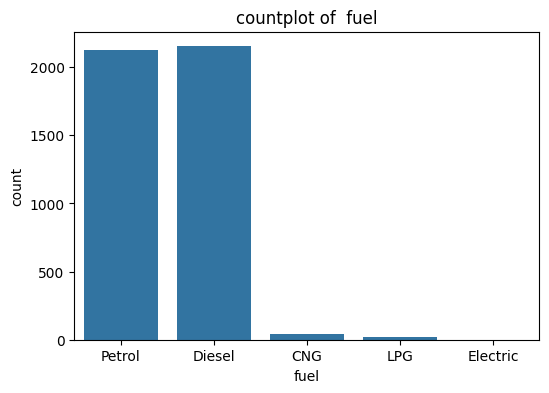

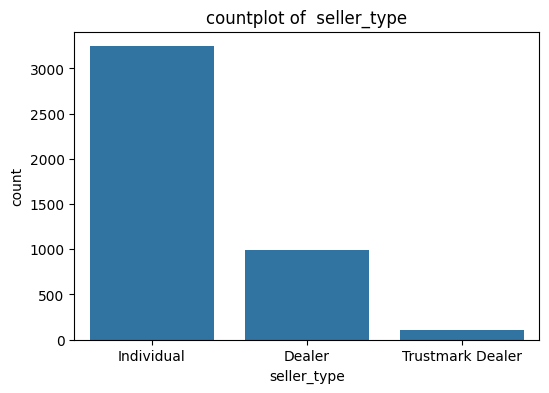

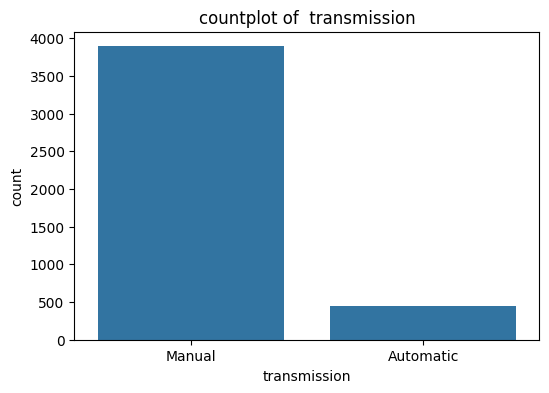

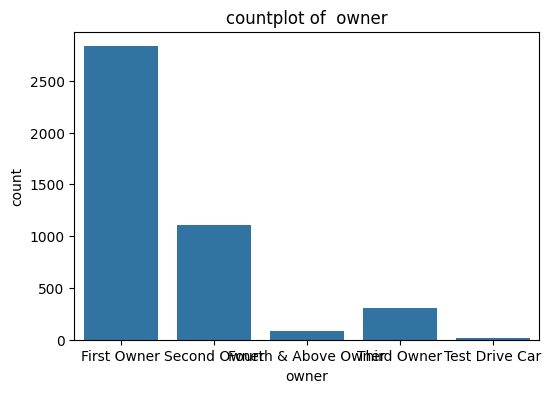

In [157]:
categorical_features = ['fuel', 'seller_type', 'transmission', 'owner'] 
for feature in categorical_features:
    plt.figure(figsize = (6,4))
    sns.countplot(data = data, x = feature)
    plt.title(f'countplot of  {feature}')
    plt.show()

**Conclusion:**

* There are **5 Fuel_Type categories**. Diesel has the highest frequency and CNG, LPG, and Electric have the least frequency.
* There are **3 Seller_Type categories**. Individual has the highest frequency and Trustmark Dealer has the least frequency.
* There are **2 Transmission categories**. Manual has the highest frequency and Automatic has the least frequency.
* There are **5 Owner categories**. First Owner has the highest frequency.


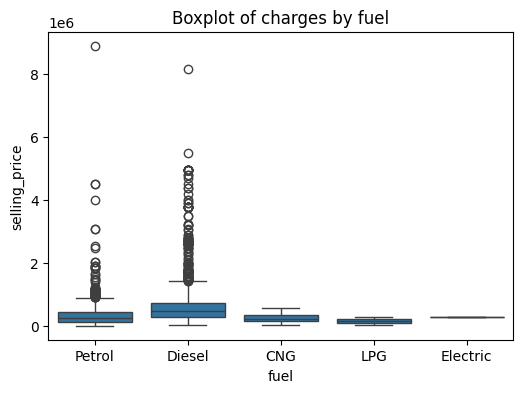

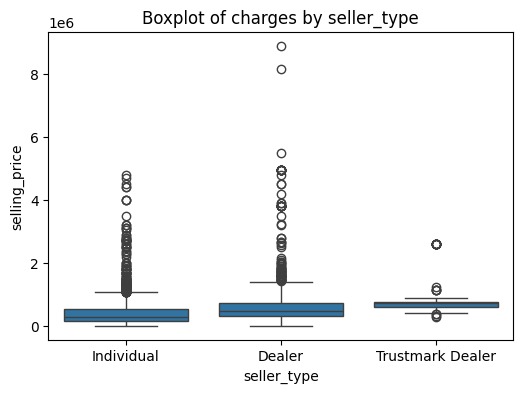

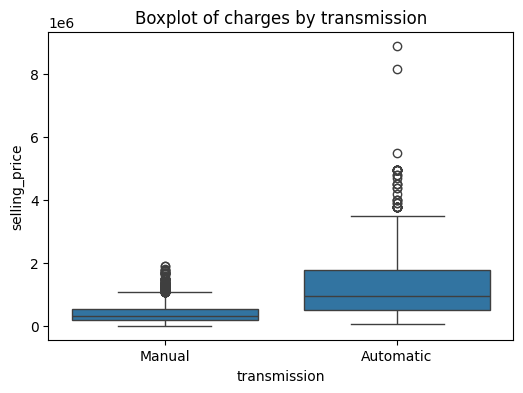

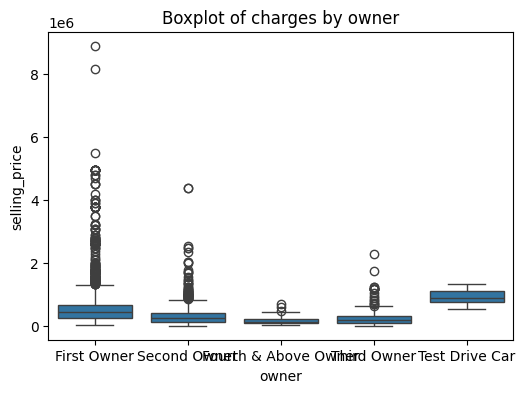

In [158]:
categorical_features = ['fuel','seller_type', 'transmission', 'owner']
for feature in categorical_features:
    plt.figure(figsize = (6,4))
    sns.boxplot(data = data, x = feature, y = 'selling_price')
    plt.title(f'Boxplot of charges by {feature}')
    plt.show()

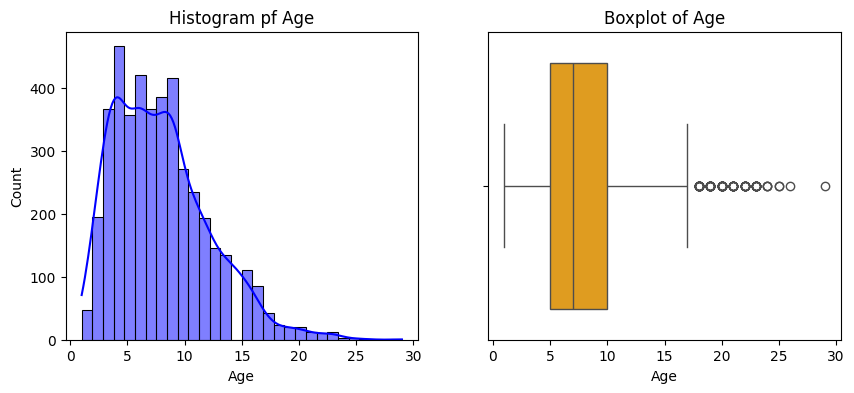

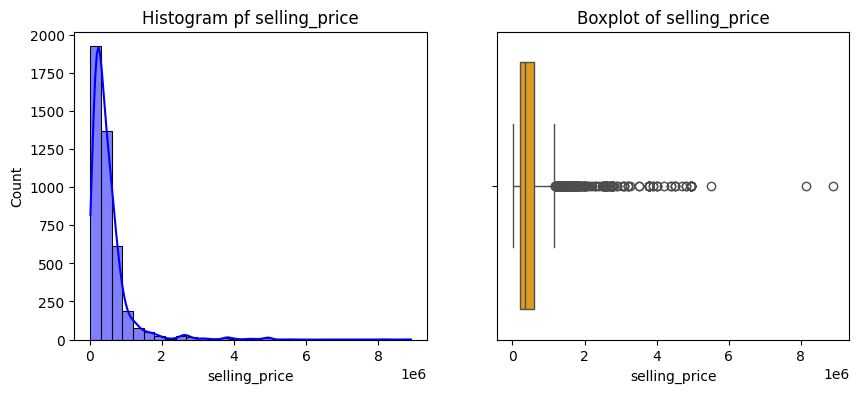

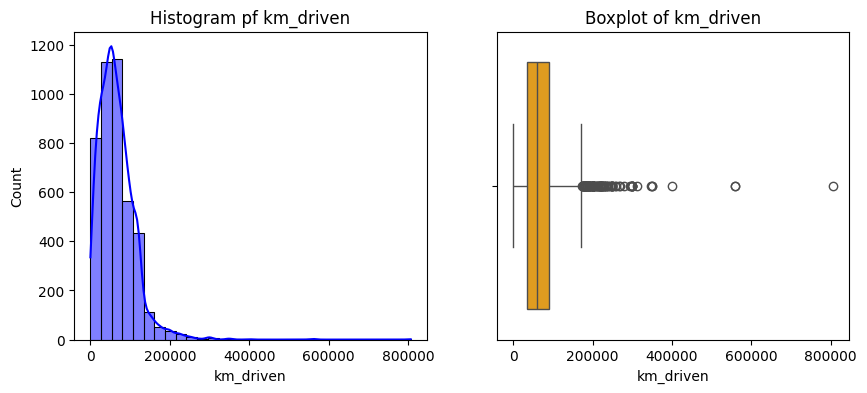

In [159]:
numeric_features = ['Age', 'selling_price', 'km_driven'] 
for feature in numeric_features:
    plt.figure(figsize = (10,4))
    plt.subplot(1,2,1)
    sns.histplot(data[feature], kde = True, bins = 30, color = 'blue')
    plt.title(f'Histogram pf {feature}')
    plt.subplot(1,2,2)
    sns.boxplot(x = data[feature], color = 'orange')
    plt.title(f'Boxplot of {feature}')
    plt.show()

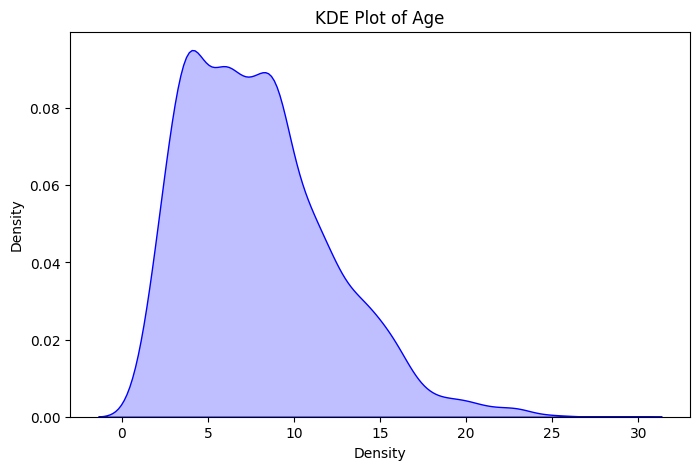

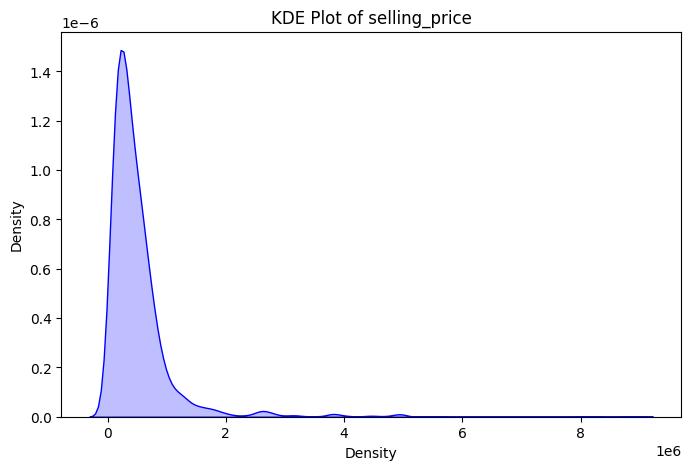

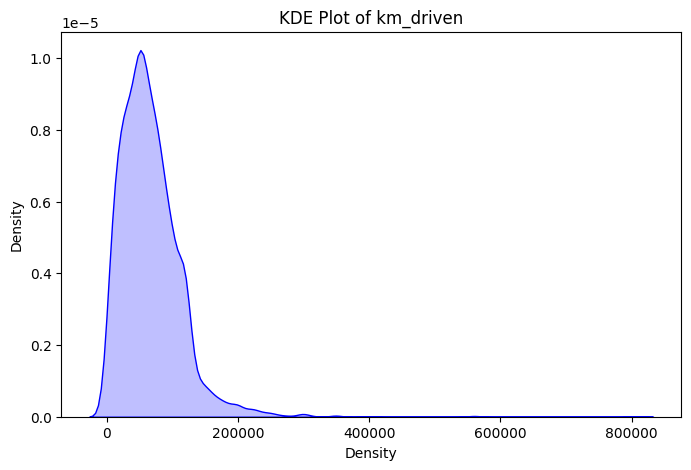

In [160]:
numeric_features = ['Age', 'selling_price', 'km_driven'] 
for feature in numeric_features:
    plt.figure(figsize = (8,5))
    sns.kdeplot(data[feature], shade = True, color = 'blue')
    plt.title(f'KDE Plot of {feature}')
    plt.xlabel('Density')
    plt.show()
    

    

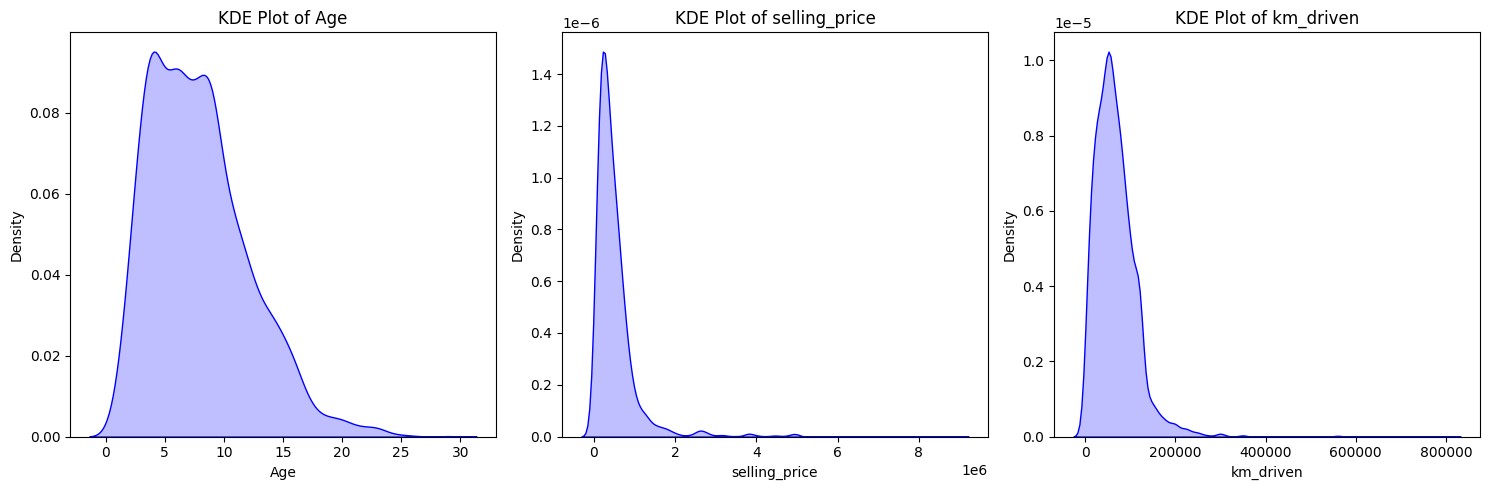

In [161]:
num_features = len(numeric_features)
plt.figure(figsize=(5 * num_features, 5))  # Adjust the figure size based on the number of features

for i, feature in enumerate(numeric_features):
    plt.subplot(1, num_features, i + 1)  # Create subplots in a single row
    sns.kdeplot(data[feature], shade=True, color='blue')
    plt.title(f'KDE Plot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()  # Adjust spacing to avoid overlap
plt.show()

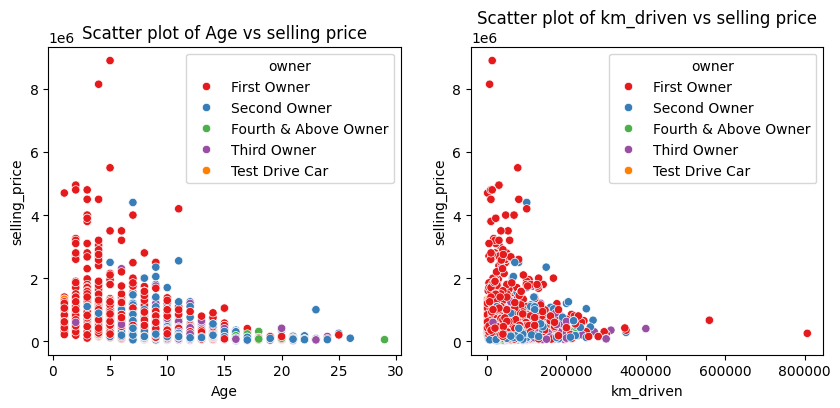

In [162]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
sns.scatterplot(data = data, x = 'Age', y = 'selling_price', hue = 'owner',palette = 'Set1')
plt.title(f'Scatter plot of Age vs selling price')
plt.subplot(1,2,2)
sns.scatterplot(data = data, x = 'km_driven', y = 'selling_price', hue = 'owner', palette = 'Set1')
plt.title(f'Scatter plot of km_driven vs selling price')
plt.show()

## One Hot Encoding On Categorical Variables

In [163]:
categorical_features = ['fuel','seller_type','transmission', 'owner']
df_encoded = pd.get_dummies(data, columns = categorical_features, drop_first = True).astype(int)
df_encoded.head(5)

,Age,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,14,60000,70000,0,0,0,1,1,0,1,0,0,0,0
1,14,135000,50000,0,0,0,1,1,0,1,0,0,0,0
2,9,600000,100000,1,0,0,0,1,0,1,0,0,0,0
3,4,250000,46000,0,0,0,1,1,0,1,0,0,0,0
4,7,450000,141000,1,0,0,0,1,0,1,0,1,0,0


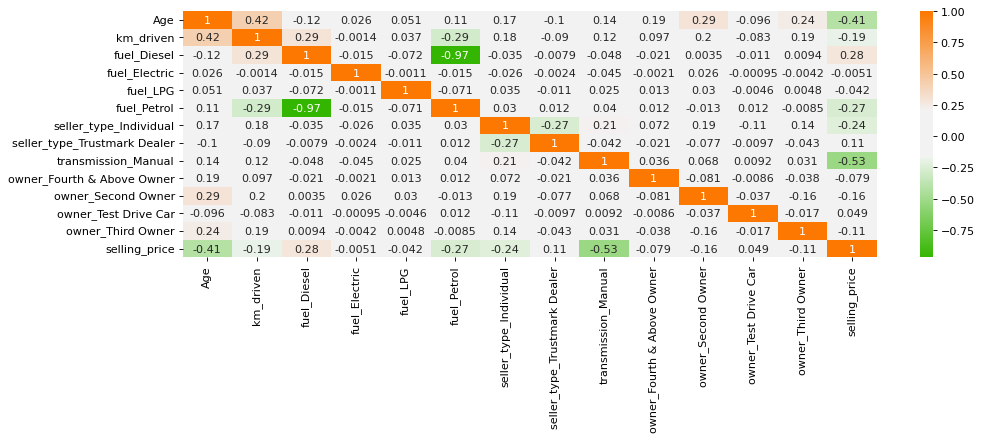

In [164]:
target = 'selling_price'
cmap = sns.diverging_palette(125,28,s = 100, l = 65, sep = 50, as_cmap = True)
fig, ax = plt.subplots(figsize = (14,4), dpi = 80)
ax = sns.heatmap(pd.concat([df_encoded.drop(target,axis = 1), df_encoded[target]], axis = 1).corr(), annot = True, cmap = cmap)
plt.show()

## Splitting The Data

In [165]:
x = df_encoded.drop('selling_price', axis = 1)
y = df_encoded['selling_price'] 


In [166]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [167]:
print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', x_test.shape)

x_train shape:  (3472, 13)
x_test shape:  (868, 13)
y_train shape:  (3472,)
y_test shape:  (868, 13)


## Scale Data using Standard Scaler

In [168]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [169]:
x_train_scaled

array([[-0.92342078, -0.98114024,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [-1.16122801, -0.34146273,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [ 0.0278081 , -0.87452732, -0.98740648, ...,  1.71884901,
        -0.06587126, -0.27553931],
       ...,
       [-0.68561356, -0.32014015,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [ 0.0278081 ,  0.29821478,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [ 0.0278081 ,  0.29821478, -0.98740648, ..., -0.58178467,
        -0.06587126, -0.27553931]], shape=(3472, 13))

## Model Training

In [170]:
from sklearn.linear_model import LinearRegression 

linear_reg = LinearRegression()
linear_reg.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [171]:
pd.DataFrame(data = np.append(linear_reg.intercept_, linear_reg.coef_), 
            index = ['Intercept'] + [col + ' coef.' for col in x.columns], columns = ['Value']).sort_values('Value', ascending = False)

,Value
Intercept,507767.468318
fuel_Diesel coef.,139914.155959
seller_type_Trustmark Dealer coef.,25320.616048
owner_Test Drive Car coef.,8570.854655
fuel_LPG coef.,3841.002203
owner_Fourth & Above Owner coef.,87.386207
owner_Third Owner coef.,-6931.174889
fuel_Petrol coef.,-10346.919035
fuel_Electric coef.,-10861.968495
owner_Second Owner coef.,-15667.732776


In [172]:
from sklearn import metrics 

def model_evaluation(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test) 
    MAE = metrics.mean_absolute_error(y_test, y_pred)
    MSE = metrics.mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    R2_Score = metrics.r2_score(y_test, y_pred)
    return pd.DataFrame([MAE,MSE,RMSE,R2_Score], index = ['MAE', 'MSE', 'RMSE','R2_Score'], columns = [model_name])
    

In [173]:
model_evaluation(linear_reg, x_train_scaled, y_train, 'Linear Reg')

,Linear Reg
MAE,2.340585e+05
MSE,1.807843e+11
RMSE,4.251874e+05
R2_Score,4.713029e-01


In [174]:
model_evaluation(linear_reg, x_test_scaled, y_test, 'Linear Reg')

,Linear Reg
MAE,2.217064e+05
MSE,1.821469e+11
RMSE,4.267867e+05
R2_Score,4.031304e-01


In [175]:
data.columns

Index(['Age', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')

In [176]:
data.dtypes

Age              int64
selling_price    int64
km_driven        int64
fuel               str
seller_type        str
transmission       str
owner              str
dtype: object

In [177]:
df_encoded.dtypes

Age                             int64
selling_price                   int64
km_driven                       int64
fuel_Diesel                     int64
fuel_Electric                   int64
fuel_LPG                        int64
fuel_Petrol                     int64
seller_type_Individual          int64
seller_type_Trustmark Dealer    int64
transmission_Manual             int64
owner_Fourth & Above Owner      int64
owner_Second Owner              int64
owner_Test Drive Car            int64
owner_Third Owner               int64
dtype: object

## Gradient Descent

In [178]:
def gradient_descent(x,y, learning_rate = 0.01, epochs = 1000):
    m = x.shape[0]  #These are the number of samples
    n = x.shape[1] # These are the Number of features (13)
    weights = np.zeros(n) # Here we are going to intializes weight to zeros, one for each feature 
    cost_history = []
    for epoch in range(epochs):
        predictions = np.dot(x,weights)  # it is a predicted values 
        errors = predictions - y # it is the prediction values - actual values

        gradients  =  (1/m) * np.dot(x.T, errors) # for to calculate the gradients 
        weights -= learning_rate * gradients # for to update the weights 
        cost = (1 / (2*m))* np.sum(errors ** 2) # Mean Squared Error Calculation 
        cost_history.append(cost)
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Cost = {cost}")
    return weights, cost_history

In [179]:
x_train_np = np.hstack((np.ones((x_train_scaled.shape[0],1)), x_train_scaled)) # Here we are adding the column of ones to x_train for intercept (bias term) 
y_train_np = y_train.values 
weights, cost_history = gradient_descent(x_train_np, y_train_np, learning_rate = 0.01, epochs = 1000)

Epoch 0: Cost = 299885435816.6771
Epoch 100: Cost = 112964193306.54724
Epoch 200: Cost = 93603939030.21584
Epoch 300: Cost = 90950274457.33
Epoch 400: Cost = 90547301900.55424
Epoch 500: Cost = 90477068818.72096
Epoch 600: Cost = 90460889984.5487
Epoch 700: Cost = 90454979903.71487
Epoch 800: Cost = 90451534807.87514
Epoch 900: Cost = 90448871963.10217


In [180]:
weights

array([ 507745.54736297, -149446.87440541,  -47552.06180049,
         87774.28574971,  -12679.75476679,   -3730.81265774,
        -62712.3654834 ,  -30166.86908034,   25469.72904028,
       -273099.9271047 ,    -704.89859069,  -16337.84151501,
          8694.79725674,   -7303.0801146 ])

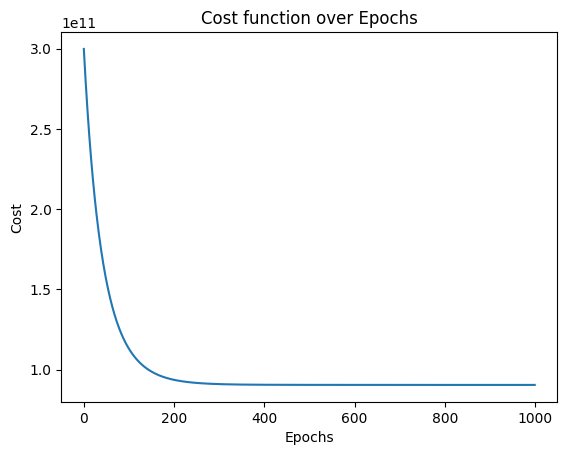

In [181]:
plt.plot(range(len(cost_history)), cost_history)
plt.title("Cost function over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

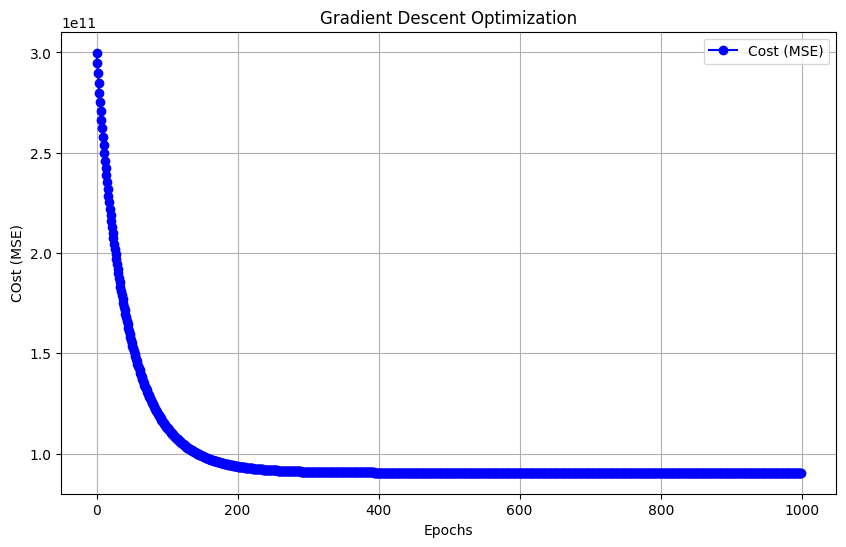

In [182]:
def visualization_gradient_descent(cost_history):
    plt.figure(figsize = (10,6))
    plt.plot(range(len(cost_history)), cost_history, marker = 'o', linestyle = '-', color = 'b' , label = 'Cost (MSE)')
    plt.title("Gradient Descent Optimization")
    plt.xlabel("Epochs")
    plt.ylabel("COst (MSE)")
    plt.grid(True)
    plt.legend()
    plt.show()
visualization_gradient_descent(cost_history)

## Assumptions of Linear Regression

In [183]:
def residuals(model, x_test, y_test):
    y_pred = model.predict(x_test) 
    return pd.DataFrame({
    'Actual':y_test, 
    'Predicted': y_pred,
    'Residuals': y_test - y_pred 
    })

In [184]:
def linear_assumption(model, x_test, y_test):
    results = residuals(model, x_test, y_test)
    fig, axes = plt.subplots(1,2, figsize = (10,3), dpi = 100) 
    sns.regplot(x = 'Predicted', y = 'Actual', data = results , lowess = True, ax = axes[0], scatter_kws = {'alpha':0.7, 'color':'blue'}, line_kws = {'color':'orange', 'ls':'--'})
    axes[0].set(title = 'Actual vs Predicted' , xlabel = 'Predicted', ylabel = 'Actual' ) 
    sns.regplot(x = 'Predicted', y = 'Residuals', data= results , lowess = True, ax = axes[1], scatter_kws = {'alpha':0.7, 'color':'blue'}, line_kws = {'color':'orange', 'ls':'--'} )
    axes[1].set(title = 'Residuals vs Predicted', xlabel = 'Predicted', ylabel = 'Residuals') 
    plt.tight_layout() 
    plt.show()
    
    

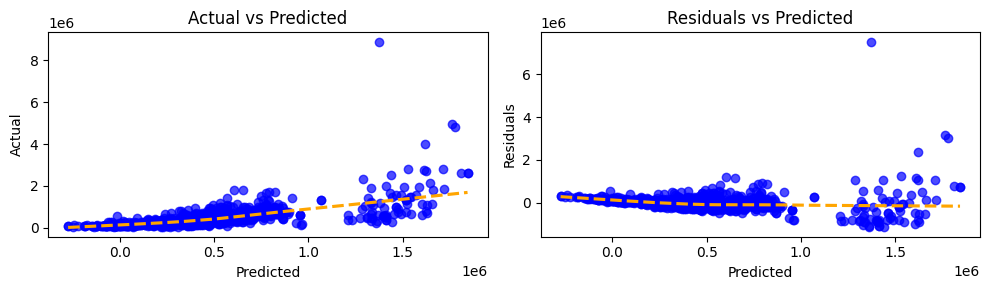

In [185]:
linear_assumption(linear_reg, x_test_scaled, y_test)

## Normality of Residuals

In [186]:
import scipy.stats as stats 
def check_normality_of_residuals(model,x_test,y_test):
    results = residuals(model,x_test,y_test)
    residuals_data = results['Residuals'] 
    plt.figure(figsize = (10,3)) 
    plt.subplot(1,2,1) 
    sns.histplot(residuals_data , kde = True , color = 'blue', bins = 30) 
    plt.title('Histogram of Residuals') 
    plt.xlabel('Residuals')
    plt.ylabel('Frequency') 

    plt.subplot(1,2,2) 
    stats.probplot(residuals_data , dist = "norm", plot = plt) 
    plt.title('Q-Q Plot of Residuals')
    plt.tight_layout() 
    plt.show()

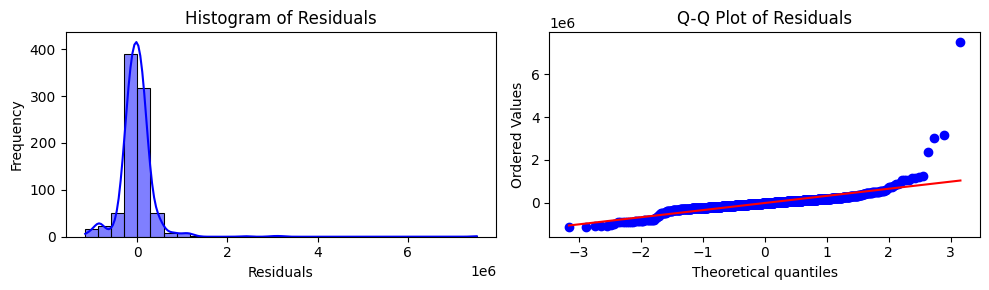

In [187]:
check_normality_of_residuals(linear_reg, x_test_scaled, y_test)

## No Multicolinearity

In [188]:
from statsmodels.stats.outliers_influence import variance_inflation_factor  
def calculate_vif(x):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = x.columns 
    vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])] 
    return vif_data 
    

In [189]:
vif_results = calculate_vif(x) 
vif_results

,Feature,VIF
0,Age,7.016427
1,km_driven,4.435080
2,fuel_Diesel,6.555573
3,fuel_Electric,1.003684
4,fuel_LPG,1.086386
5,fuel_Petrol,6.843066
6,seller_type_Individual,4.810789
7,seller_type_Trustmark Dealer,1.108127
8,transmission_Manual,9.739791
9,owner_Fourth & Above Owner,1.108982



- Age (7.02) and fuel_Petrol (6.84): Indicate moderate multicollinearity. You might want to investigate these variables further or consider their relationships with other features.
- fuel_Diesel (6.56): Also shows moderate multicollinearity and needs review.
- transmission_Manual (9.74): Has the highest VIF, approaching problematic multicollinearity. This feature might be highly correlated with others.
- km_driven (4.44), seller_type_Individual (4.81): Show acceptable multicollinearity levels.
- Remaining features have VIF < 2, indicating little to no multicollinearity.

## Homoscedasticity

In [190]:
def homoscedasticity_assumption(model, x_test, y_test):
    print('The orange line should be flat') 
    df_results = residuals(model, x_test, y_test) 
    fig = plt.figure(figsize = (6,6), dpi = 80) 
    sns.regplot(x = 'Predicted', y = 'Residuals', data = df_results, lowess = True, color = '#0055ff', line_kws = {'color':'#ff7000', 'ls':'--', 'lw':2.5}) 
    plt.axhline(y = 0, color = '#23bf00', lw = 1) 
    plt.title('residuals vs Predicted Values', fontsize = 15) 
    plt.xlabel('Predicted Values', fontsize = 15) 
    plt.ylabel('Residuals', fontsize = 12) 
    plt.show()

The orange line should be flat


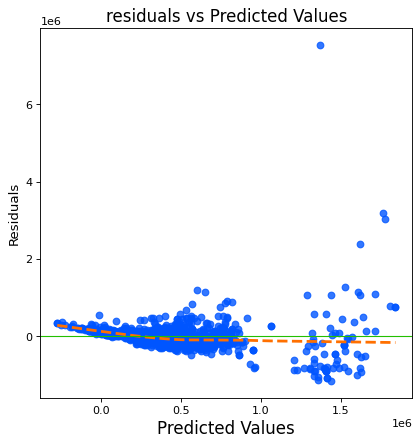

In [191]:
homoscedasticity_assumption(linear_reg,x_test_scaled, y_test)

## Ride Regression

In [192]:
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(3472, 13)
(868, 13)


In [193]:
from sklearn.linear_model import Ridge 
ridge_reg = Ridge(alpha = 10) #Here alpha means the Lambda 
ridge_reg.fit(x_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [194]:
ridge_train_pred = ridge_reg.predict(x_train_scaled) 
ridge_test_pred = ridge_reg.predict(x_test_scaled)

In [195]:
ridge_train_mse = metrics.mean_squared_error(y_train, ridge_train_pred) 
ridge_test_mse = metrics.mean_squared_error(y_test, ridge_test_pred) 
print("Ridge Regression:") 
print(f"Train MSE: {ridge_train_mse:.4f}")
print(f"Test MSE: {ridge_test_mse:.4f}")

Ridge Regression:
Train MSE: 180787728311.5564
Test MSE: 182093918913.6953


In [196]:
np.sqrt(ridge_train_mse)

np.float64(425191.4019727544)

In [197]:
np.sqrt(ridge_test_mse)

np.float64(426724.6406216722)

In [198]:
ridge_coefficients = ridge_reg.coef_ 
retained_features = np.where(ridge_coefficients != 0)[0] 
print("Ridge Retained Features (Indices): ", retained_features) 
print("Ridge Coefficients: ", ridge_coefficients)

Ridge Retained Features (Indices):  [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Ridge Coefficients:  [-1.49916692e+05 -4.72415551e+04  1.31717181e+05 -1.10806031e+04
  2.64917104e+03 -1.84129872e+04 -3.04075813e+04  2.52913522e+04
 -2.72021583e+05 -1.20530561e+02 -1.58639658e+04  8.56984367e+03
 -7.06678438e+03]


In [199]:
pd.DataFrame(data = np.append(ridge_reg.intercept_, ridge_reg.coef_), 
             index = ['Intercept'] + [col + " Coef," for col in x.columns], 
             columns = ['Value']).sort_values('Value', ascending = False)

,Value
Intercept,507767.468318
"fuel_Diesel Coef,",131717.180989
"seller_type_Trustmark Dealer Coef,",25291.352202
"owner_Test Drive Car Coef,",8569.843670
"fuel_LPG Coef,",2649.171036
"owner_Fourth & Above Owner Coef,",-120.530561
"owner_Third Owner Coef,",-7066.784375
"fuel_Electric Coef,",-11080.603078
"owner_Second Owner Coef,",-15863.965821
"fuel_Petrol Coef,",-18412.987204


## Lasso Regression

In [232]:
from sklearn.linear_model import Lasso 
lasso_reg = Lasso(alpha = 10000) 
lasso_reg.fit(x_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [233]:
lasso_train_pred = lasso_reg.predict(x_train_scaled) 
lasso_test_pred = lasso_reg.predict(x_test_scaled)

In [234]:
lasso_train_mse = metrics.mean_squared_error(y_train, lasso_train_pred) 
lasso_test_mse = metrics.mean_squared_error(y_test, lasso_test_pred) 
print("Lasso Regression:") 
print(f"Train MSE: {lasso_train_mse:.4f}")
print(f"Test MSE: {lasso_test_mse:.4f}")

Lasso Regression:
Train MSE: 181490010182.6936
Test MSE: 181576480911.8141


In [235]:
np.sqrt(lasso_train_mse)

np.float64(426016.4435590411)

In [236]:
np.sqrt(lasso_test_mse)

np.float64(426117.9190222045)

In [237]:
lasso_coefficients = lasso_reg.coef_ 
retained_features = np.where(lasso_coefficients != 0)[0] 
print("Lasso Retained Features (Indices): ", retained_features) 
print("Lasso Coefficients: ", lasso_coefficients)

Lasso Retained Features (Indices):  [ 0  1  2  3  5  6  7  8 10]
Lasso Coefficients:  [-153113.90250726  -37782.73835152  135092.09300107    -510.53808948
       0.           -2041.79419042  -28564.84862789   17200.89375005
 -264809.27554849      -0.           -7461.38018526       0.
      -0.        ]


In [238]:
pd.DataFrame(data = np.append(lasso_reg.intercept_, lasso_reg.coef_), 
             index = ['Intercept'] + [col + " Coef," for col in x.columns], 
             columns = ['Value']).sort_values('Value', ascending = False)

,Value
Intercept,507767.468318
"fuel_Diesel Coef,",135092.093001
"seller_type_Trustmark Dealer Coef,",17200.893750
"fuel_LPG Coef,",0.000000
"owner_Fourth & Above Owner Coef,",-0.000000
"owner_Test Drive Car Coef,",0.000000
"owner_Third Owner Coef,",-0.000000
"fuel_Electric Coef,",-510.538089
"fuel_Petrol Coef,",-2041.794190
"owner_Second Owner Coef,",-7461.380185
